# 📊 TravelMate AI - 20 Evaluation

This notebook evaluates the current TravelMate AI system.

## Important evaluation principle

We do **not** currently have a human-labelled ground-truth dataset such as:

```text
user → places they actually liked
```

Therefore we should **not claim real-world accuracy, precision, recall, or NDCG from fabricated labels**.

Instead, this notebook measures:

```text
1. 🏙️ City correctness
2. 🎯 Preference alignment
3. 🔀 Recommendation diversity
4. 📈 Recommendation coverage
5. 🧠 Personalization sensitivity
6. ⏱️ Itinerary feasibility
7. 📍 Geographic efficiency
8. 📊 Score distribution
```

These are prototype evaluation metrics. Later, real user feedback can be added for stronger offline evaluation.

---

## Evaluation architecture

```text
Multi-city dataset
       ↓
Shared recommender
       ↓
Test scenarios
       ├── city correctness
       ├── interest alignment
       ├── diversity
       └── personalization
       ↓
Shared itinerary engine
       ├── budget validity
       ├── city integrity
       └── travel efficiency
       ↓
📊 Evaluation report
```


## 1. Imports and paths

In [1]:
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_places, available_cities
from src.recommender import TravelRecommender
from src.itinerary import generate_itinerary

print("✅ Evaluation environment ready")


d:\college_work\PG\linkedIn_projects\TravelMate-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Evaluation environment ready


## 2. Load the dataset

In [2]:
df = load_places()

print("Dataset shape:", df.shape)
print("\nCities:")
print(df["city"].value_counts())

print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (120, 27)

Cities:
city
Manali       20
Goa          20
Jaipur       20
Udaipur      20
Rishikesh    20
Shimla       20
Name: count, dtype: int64

Columns:
['place_id', 'name', 'city', 'address', 'country', 'latitude', 'longitude', 'rating', 'reviews', 'category', 'source_query', 'name_clean', 'category_clean', 'feature_text', 'nature', 'history', 'culture', 'adventure', 'photography', 'shopping', 'religious', 'family', 'travel_tags', 'estimated_visit_minutes', 'recommendation_text', 'rating_score', 'popularity_score']


## 3. Build the evaluation recommender

The evaluation uses the same shared recommender that the application uses.

For reproducibility, the notebook generates embeddings if the saved multi-city embedding matrix is unavailable or incompatible.


In [3]:
embedding_path = (
    PROJECT_ROOT
    / "data"
    / "embeddings"
    / "multi_city_place_embeddings.npy"
)

embeddings = None

if embedding_path.exists():
    try:
        candidate_embeddings = np.load(
            embedding_path
        )

        if len(candidate_embeddings) == len(df):
            embeddings = candidate_embeddings
            print("✅ Loaded saved multi-city embeddings")
        else:
            print(
                "⚠️ Saved embedding row count does not match dataset."
            )
    except Exception as exc:
        print(
            "⚠️ Could not load saved embeddings:",
            exc
        )

evaluator = TravelRecommender(
    df=df,
    place_embeddings=embeddings,
)

print(
    "Embedding shape:",
    evaluator.place_embeddings.shape
)


✅ Loaded saved multi-city embeddings


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4211.11it/s]


Embedding shape: (120, 384)


## 4. Define test preference profiles

These profiles simulate different traveller types.

The profiles are **evaluation scenarios**, not ground truth.


In [4]:
PREFERENCE_PROFILES = {
    "nature_photographer": {
        "nature": 1.0,
        "history": 0.1,
        "culture": 0.2,
        "adventure": 0.4,
        "photography": 1.0,
        "shopping": 0.1,
        "religious": 0.0,
        "family": 0.3,
    },
    "history_culture": {
        "nature": 0.1,
        "history": 1.0,
        "culture": 1.0,
        "adventure": 0.0,
        "photography": 0.8,
        "shopping": 0.3,
        "religious": 0.3,
        "family": 0.3,
    },
    "adventure": {
        "nature": 0.7,
        "history": 0.1,
        "culture": 0.1,
        "adventure": 1.0,
        "photography": 0.5,
        "shopping": 0.0,
        "religious": 0.0,
        "family": 0.2,
    },
    "family": {
        "nature": 0.7,
        "history": 0.2,
        "culture": 0.3,
        "adventure": 0.1,
        "photography": 0.4,
        "shopping": 0.2,
        "religious": 0.1,
        "family": 1.0,
    },
    "shopping_culture": {
        "nature": 0.1,
        "history": 0.5,
        "culture": 0.8,
        "adventure": 0.0,
        "photography": 0.4,
        "shopping": 1.0,
        "religious": 0.2,
        "family": 0.3,
    },
}

QUERY_PROFILES = {
    "nature_photographer":
        "peaceful scenic places surrounded by nature for photography",
    "history_culture":
        "historical cultural forts palaces temples and heritage places",
    "adventure":
        "adventure trekking outdoor and exciting travel experiences",
    "family":
        "family friendly relaxing places and activities",
    "shopping_culture":
        "local markets shopping and cultural experiences",
}

print(
    "Profiles:",
    list(PREFERENCE_PROFILES)
)


Profiles: ['nature_photographer', 'history_culture', 'adventure', 'family', 'shopping_culture']


## 5. Add baseline itinerary metadata

The application infers these fields before sending recommendations to the itinerary engine.

The same simple rules are reproduced here for evaluation consistency.


In [5]:
def infer_activity_type(text):
    text = str(text).lower()

    if "waterfall" in text or "falls" in text:
        return "waterfall"

    if "rafting" in text:
        return "rafting"

    if "trek" in text:
        return "trekking"

    if "viewpoint" in text or "view point" in text:
        return "viewpoint"

    if any(
        x in text
        for x in [
            "temple",
            "church",
            "mosque",
            "gurudwara",
            "monastery",
        ]
    ):
        return "religious_site"

    if any(
        x in text
        for x in [
            "fort",
            "palace",
            "museum",
            "heritage",
            "castle",
        ]
    ):
        return "heritage"

    if any(
        x in text
        for x in [
            "market",
            "bazaar",
            "mall",
            "shopping",
        ]
    ):
        return "shopping"

    if any(
        x in text
        for x in [
            "beach",
            "lake",
            "river",
            "park",
            "forest",
            "garden",
        ]
    ):
        return "nature"

    if "snow" in text or "ski" in text:
        return "winter_experience"

    return "sightseeing"


def estimate_visit_minutes(activity_type):
    return {
        "waterfall": 90,
        "rafting": 120,
        "trekking": 150,
        "viewpoint": 45,
        "religious_site": 60,
        "heritage": 120,
        "shopping": 90,
        "nature": 90,
        "winter_experience": 90,
        "sightseeing": 60,
    }.get(activity_type, 60)


def estimate_price_level(text):
    text = str(text).lower()

    if (
        "rafting" in text
        or "ski" in text
        or "adventure" in text
    ):
        return 3

    if any(
        x in text
        for x in [
            "shopping",
            "market",
            "bazaar",
            "mall",
        ]
    ):
        return 2

    return 1


def prepare_itinerary_candidates(
    result
):
    result = result.copy()

    text = (
        result["name"].fillna("").astype(str)
        + " "
        + result["category"].fillna("").astype(str)
    )

    result["activity_type"] = (
        text.apply(infer_activity_type)
    )

    result["estimated_visit_minutes"] = (
        result["activity_type"]
        .apply(estimate_visit_minutes)
    )

    result["estimated_price_level"] = (
        text.apply(estimate_price_level)
    )

    return result


## 6. Evaluation helper functions

In [6]:
INTEREST_COLUMNS = [
    "nature",
    "history",
    "culture",
    "adventure",
    "photography",
    "shopping",
    "religious",
    "family",
]


def preference_alignment(
    recommendations,
    preferences,
):
    values = (
        recommendations[INTEREST_COLUMNS]
        .fillna(0)
        .astype(float)
        .to_numpy()
    )

    preference_vector = np.array(
        [
            preferences[col]
            for col in INTEREST_COLUMNS
        ],
        dtype=float,
    )

    denominator = (
        np.linalg.norm(preference_vector)
        * np.linalg.norm(values, axis=1)
    )

    scores = np.zeros(
        len(values),
        dtype=float
    )

    valid = denominator > 0

    scores[valid] = (
        values[valid]
        @ preference_vector
    ) / denominator[valid]

    return float(
        np.mean(scores)
    )


def recommendation_diversity(
    recommendations,
):
    if recommendations.empty:
        return 0.0

    unique_activities = (
        recommendations["activity_type"]
        .nunique()
        if "activity_type"
        in recommendations.columns
        else recommendations["category"].nunique()
    )

    return (
        unique_activities
        / len(recommendations)
    )


def city_correctness(
    recommendations,
    requested_city,
):
    if recommendations.empty:
        return 0.0

    return float(
        recommendations["city"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(
            requested_city
            .strip()
            .lower()
        )
        .mean()
    )


def coverage_at_k(
    recommended_names,
    total_city_places,
):
    if total_city_places <= 0:
        return 0.0

    return len(
        set(recommended_names)
    ) / total_city_places


def itinerary_daily_totals(
    itinerary,
):
    if itinerary.empty:
        return pd.DataFrame(
            columns=[
                "city",
                "day",
                "total_minutes",
            ]
        )

    return (
        itinerary
        .assign(
            total_minutes=lambda x:
                x["travel_before_minutes"]
                + x["visit_minutes"]
        )
        .groupby(
            ["city", "day"]
        )["total_minutes"]
        .sum()
        .reset_index()
    )


print("✅ Evaluation helpers ready")


✅ Evaluation helpers ready


# 🎯 7. Evaluation A: City correctness

This should be 100%.

A Goa query returning a Manali attraction is a critical system error.


In [7]:
city_results = []

for city in available_cities(df):

    for profile_name in PREFERENCE_PROFILES:

        result = evaluator.recommend(
            destination=city,
            query=QUERY_PROFILES[
                profile_name
            ],
            user_preferences=PREFERENCE_PROFILES[
                profile_name
            ],
            top_n=5,
        )

        city_results.append({
            "city": city,
            "profile": profile_name,
            "city_correctness":
                city_correctness(
                    result,
                    city
                ),
            "recommendations":
                len(result),
        })

city_correctness_df = pd.DataFrame(
    city_results
)

city_correctness_df.head(10)


,city,profile,city_correctness,recommendations
0,Goa,nature_photographer,1.0,5
1,Goa,history_culture,1.0,5
2,Goa,adventure,1.0,5
3,Goa,family,1.0,5
4,Goa,shopping_culture,1.0,5
5,Jaipur,nature_photographer,1.0,5
6,Jaipur,history_culture,1.0,5
7,Jaipur,adventure,1.0,5
8,Jaipur,family,1.0,5
9,Jaipur,shopping_culture,1.0,5


In [8]:
print(
    "Mean city correctness:",
    round(
        city_correctness_df[
            "city_correctness"
        ].mean(),
        4
    )
)

assert (
    city_correctness_df[
        "city_correctness"
    ].eq(1.0).all()
)

print(
    "✅ City correctness = 100%"
)


Mean city correctness: 1.0
✅ City correctness = 100%


# 🎯 8. Evaluation B: Preference alignment

This is a proxy metric.

It measures whether recommended places contain the same interest categories as the user's preference profile.

It is **not** a human satisfaction score.


In [9]:
alignment_rows = []

for city in available_cities(df):

    for profile_name in PREFERENCE_PROFILES:

        result = evaluator.recommend(
            destination=city,
            query=QUERY_PROFILES[
                profile_name
            ],
            user_preferences=PREFERENCE_PROFILES[
                profile_name
            ],
            top_n=5,
        )

        alignment_rows.append({
            "city": city,
            "profile": profile_name,
            "preference_alignment":
                preference_alignment(
                    result,
                    PREFERENCE_PROFILES[
                        profile_name
                    ],
                ),
        })

alignment_df = pd.DataFrame(
    alignment_rows
)

alignment_summary = (
    alignment_df
    .groupby("profile")[
        "preference_alignment"
    ]
    .mean()
    .reset_index()
    .sort_values(
        "preference_alignment",
        ascending=False,
    )
)

alignment_summary


,profile,preference_alignment
3,nature_photographer,0.789987
2,history_culture,0.740448
1,family,0.729928
4,shopping_culture,0.555294
0,adventure,0.548008


# 🔀 9. Evaluation C: Recommendation diversity

A recommender should not return five almost-identical places every time.

Here we use:

```text
unique activity/category types
--------------------------------
number of recommendations
```

as a simple diversity proxy.


In [10]:
diversity_rows = []

for city in available_cities(df):

    for profile_name in PREFERENCE_PROFILES:

        result = evaluator.recommend(
            destination=city,
            query=QUERY_PROFILES[
                profile_name
            ],
            user_preferences=PREFERENCE_PROFILES[
                profile_name
            ],
            top_n=5,
        )

        result = prepare_itinerary_candidates(
            result
        )

        diversity_rows.append({
            "city": city,
            "profile": profile_name,
            "diversity":
                recommendation_diversity(
                    result
                ),
        })

diversity_df = pd.DataFrame(
    diversity_rows
)

diversity_summary = (
    diversity_df
    .groupby("profile")["diversity"]
    .mean()
    .reset_index()
    .sort_values(
        "diversity",
        ascending=False,
    )
)

diversity_summary


,profile,diversity
1,family,0.633333
0,adventure,0.600000
4,shopping_culture,0.533333
2,history_culture,0.500000
3,nature_photographer,0.466667


# 📈 10. Evaluation D: Recommendation coverage

Coverage asks how much of the available destination catalogue is exposed by the top-K recommendations across test scenarios.

Because repeated recommendations are expected, this metric is calculated across **all profile/city tests**.


In [11]:
coverage_rows = []

for city in available_cities(df):

    city_names = set(
        df.loc[
            df["city"] == city,
            "name",
        ]
        .astype(str)
    )

    recommended_names = set()

    for profile_name in PREFERENCE_PROFILES:

        result = evaluator.recommend(
            destination=city,
            query=QUERY_PROFILES[
                profile_name
            ],
            user_preferences=PREFERENCE_PROFILES[
                profile_name
            ],
            top_n=5,
        )

        recommended_names.update(
            result["name"].astype(str)
        )

    coverage_rows.append({
        "city": city,
        "unique_recommended_places":
            len(recommended_names),
        "available_places":
            len(city_names),
        "coverage":
            coverage_at_k(
                recommended_names,
                len(city_names),
            ),
    })

coverage_df = pd.DataFrame(
    coverage_rows
)

coverage_df


,city,unique_recommended_places,available_places,coverage
0,Goa,13,20,0.65
1,Jaipur,10,20,0.50
2,Manali,17,20,0.85
3,Rishikesh,10,20,0.50
4,Shimla,10,20,0.50
5,Udaipur,10,20,0.50


# 🧠 11. Evaluation E: Personalization sensitivity

A useful recommender should change its recommendations when the user's interests change.

We compare two intentionally different profiles in the same city.


In [12]:
def jaccard_similarity(
    set_a,
    set_b,
):
    union = set_a | set_b

    if not union:
        return 1.0

    return len(
        set_a & set_b
    ) / len(union)


personalization_rows = []

profile_pairs = [
    (
        "nature_photographer",
        "history_culture"
    ),
    (
        "nature_photographer",
        "adventure"
    ),
    (
        "family",
        "shopping_culture"
    ),
]

for city in available_cities(df):

    for profile_a, profile_b in profile_pairs:

        result_a = evaluator.recommend(
            destination=city,
            query=QUERY_PROFILES[profile_a],
            user_preferences=PREFERENCE_PROFILES[profile_a],
            top_n=5,
        )

        result_b = evaluator.recommend(
            destination=city,
            query=QUERY_PROFILES[profile_b],
            user_preferences=PREFERENCE_PROFILES[profile_b],
            top_n=5,
        )

        names_a = set(
            result_a["name"].astype(str)
        )

        names_b = set(
            result_b["name"].astype(str)
        )

        similarity = jaccard_similarity(
            names_a,
            names_b,
        )

        personalization_rows.append({
            "city": city,
            "profile_a": profile_a,
            "profile_b": profile_b,
            "jaccard_similarity": similarity,
            "recommendation_change":
                1.0 - similarity,
        })

personalization_df = pd.DataFrame(
    personalization_rows
)

personalization_df.head(10)


,city,profile_a,profile_b,jaccard_similarity,recommendation_change
0,Goa,nature_photographer,history_culture,0.000000,1.000000
1,Goa,nature_photographer,adventure,0.428571,0.571429
2,Goa,family,shopping_culture,0.250000,0.750000
3,Jaipur,nature_photographer,history_culture,0.428571,0.571429
4,Jaipur,nature_photographer,adventure,1.000000,0.000000
5,Jaipur,family,shopping_culture,0.000000,1.000000
6,Manali,nature_photographer,history_culture,0.111111,0.888889
7,Manali,nature_photographer,adventure,0.111111,0.888889
8,Manali,family,shopping_culture,0.000000,1.000000
9,Rishikesh,nature_photographer,history_culture,0.428571,0.571429


A higher `recommendation_change` means the system reacts more strongly to different preferences.

This metric is not automatically "higher is always better", because excessive change could also indicate instability.

We mainly use it to confirm that **the model is responsive to different user profiles**.


In [13]:
personalization_summary = (
    personalization_df
    .groupby("city")[
        "recommendation_change"
    ]
    .mean()
    .reset_index()
)

personalization_summary


,city,recommendation_change
0,Goa,0.773810
1,Jaipur,0.523810
2,Manali,0.925926
3,Rishikesh,0.571429
4,Shimla,0.736772
5,Udaipur,0.703704


# ⏱️ 12. Evaluation F: Itinerary feasibility

The itinerary should respect its hard daily planning budget.

We test all six cities.


In [14]:
itinerary_rows = []

for city in available_cities(df):

    recommendations = evaluator.recommend(
        destination=city,
        query="best places for a memorable trip",
        user_preferences=PREFERENCE_PROFILES[
            "family"
        ],
        top_n=12,
    )

    recommendations = (
        prepare_itinerary_candidates(
            recommendations
        )
    )

    plan = generate_itinerary(
        candidates=recommendations,
        days=3,
        max_day_minutes=7 * 60,
        average_speed_kmph=25,
    )

    totals = itinerary_daily_totals(
        plan
    )

    within_budget = (
        totals["total_minutes"]
        <= 7 * 60 + 1e-9
    ).all()

    city_valid = (
        not plan.empty
        and plan["city"]
        .eq(city)
        .all()
    )

    itinerary_rows.append({
        "city": city,
        "scheduled_stops":
            len(plan),
        "days_used":
            plan["day"].nunique()
            if not plan.empty
            else 0,
        "budget_valid":
            bool(within_budget),
        "city_valid":
            bool(city_valid),
        "average_daily_minutes":
            (
                totals["total_minutes"].mean()
                if not totals.empty
                else 0
            ),
    })

itinerary_eval_df = pd.DataFrame(
    itinerary_rows
)

itinerary_eval_df


,city,scheduled_stops,days_used,budget_valid,city_valid,average_daily_minutes
0,Goa,9,3,True,True,372.696667
1,Jaipur,11,3,True,True,388.996667
2,Manali,12,3,True,True,375.830000
3,Rishikesh,12,3,True,True,344.926667
4,Shimla,12,3,True,True,292.333333
5,Udaipur,12,3,True,True,378.450000


In [15]:
assert itinerary_eval_df[
    "budget_valid"
].all()

assert itinerary_eval_df[
    "city_valid"
].all()

print(
    "✅ All generated itineraries satisfy "
    "city and daily-budget constraints."
)


✅ All generated itineraries satisfy city and daily-budget constraints.


# 📍 13. Evaluation G: Geographic efficiency

We calculate average travel time between consecutive stops.

Lower travel time generally means a more geographically efficient plan.

This is a heuristic because the prototype uses straight-line distance plus an assumed average speed, not live road routing.


In [16]:
geo_rows = []

for city in available_cities(df):

    recommendations = evaluator.recommend(
        destination=city,
        query="best places for a memorable trip",
        user_preferences=PREFERENCE_PROFILES[
            "nature_photographer"
        ],
        top_n=12,
    )

    recommendations = (
        prepare_itinerary_candidates(
            recommendations
        )
    )

    plan = generate_itinerary(
        recommendations,
        days=3,
        max_day_minutes=7 * 60,
        average_speed_kmph=25,
    )

    if plan.empty:
        avg_travel = 0.0
        total_travel = 0.0
    else:
        avg_travel = float(
            plan["travel_before_minutes"].mean()
        )
        total_travel = float(
            plan["travel_before_minutes"].sum()
        )

    geo_rows.append({
        "city": city,
        "average_travel_minutes":
            round(avg_travel, 2),
        "total_travel_minutes":
            round(total_travel, 2),
    })

geographic_efficiency_df = pd.DataFrame(
    geo_rows
)

geographic_efficiency_df


,city,average_travel_minutes,total_travel_minutes
0,Goa,27.58,248.19
1,Jaipur,2.17,23.84
2,Manali,3.56,42.76
3,Rishikesh,2.84,34.13
4,Shimla,2.06,24.77
5,Udaipur,2.69,32.29


# 📊 14. Evaluation H: Score distribution

Look at the recommendation scores across destinations.

We want to check that the model produces sensible score variation rather than identical values everywhere.


In [17]:
score_rows = []

for city in available_cities(df):

    for profile_name in PREFERENCE_PROFILES:

        result = evaluator.recommend(
            destination=city,
            query=QUERY_PROFILES[
                profile_name
            ],
            user_preferences=PREFERENCE_PROFILES[
                profile_name
            ],
            top_n=5,
        )

        for score in result["final_score"]:
            score_rows.append({
                "city": city,
                "profile": profile_name,
                "final_score": float(score),
            })

scores_df = pd.DataFrame(
    score_rows
)

scores_df.describe()


,final_score
count,150.000000
mean,0.554864
std,0.085751
min,0.371237
25%,0.490082
50%,0.554136
75%,0.626187
max,0.744552


## 15. Visualize key evaluation metrics

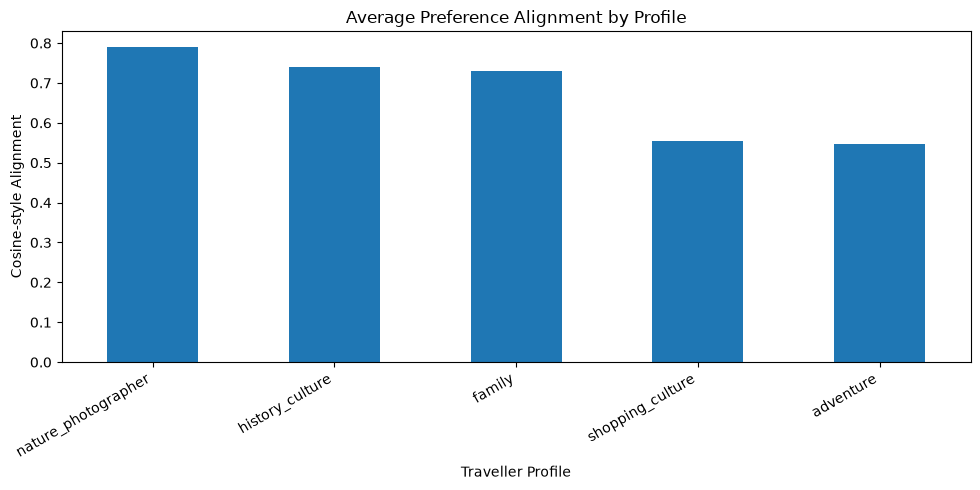

In [18]:
plt.figure(
    figsize=(10, 5)
)

(
    alignment_summary
    .set_index("profile")[
        "preference_alignment"
    ]
    .plot(
        kind="bar"
    )
)

plt.title(
    "Average Preference Alignment by Profile"
)

plt.ylabel(
    "Cosine-style Alignment"
)

plt.xlabel(
    "Traveller Profile"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


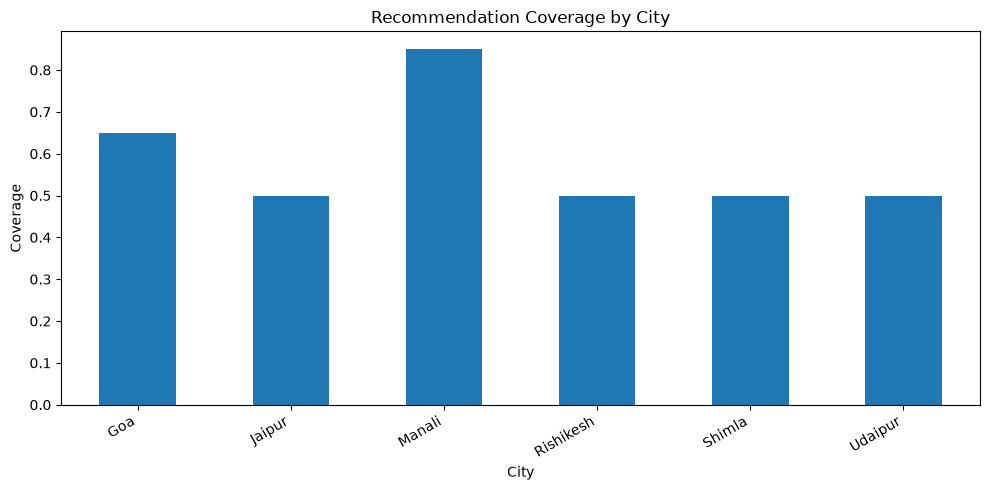

In [19]:
plt.figure(
    figsize=(10, 5)
)

coverage_df.set_index(
    "city"
)["coverage"].plot(
    kind="bar"
)

plt.title(
    "Recommendation Coverage by City"
)

plt.ylabel(
    "Coverage"
)

plt.xlabel(
    "City"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


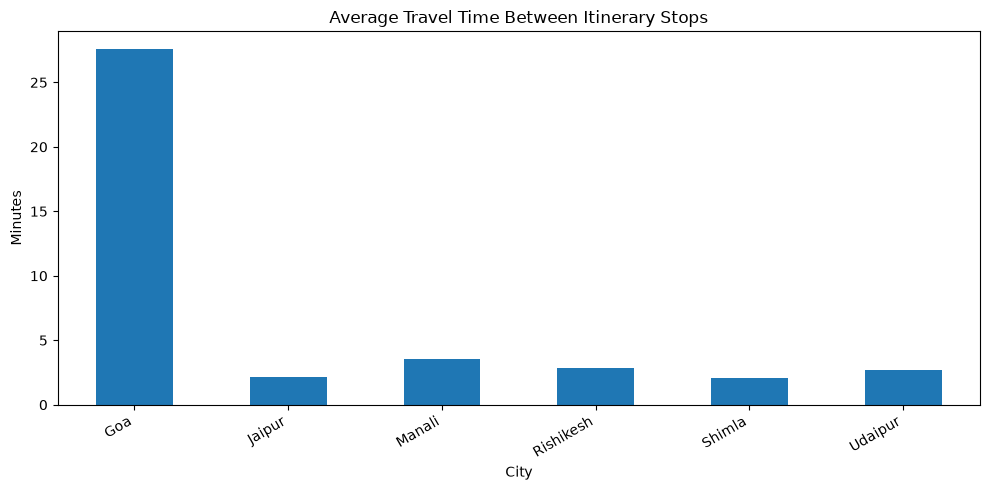

In [20]:
plt.figure(
    figsize=(10, 5)
)

geographic_efficiency_df.set_index(
    "city"
)["average_travel_minutes"].plot(
    kind="bar"
)

plt.title(
    "Average Travel Time Between Itinerary Stops"
)

plt.ylabel(
    "Minutes"
)

plt.xlabel(
    "City"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


# 🧪 16. Create the final evaluation report

This combines the main metrics into a compact report suitable for README/documentation.


In [21]:
evaluation_report = pd.DataFrame({
    "metric": [
        "City correctness",
        "Mean preference alignment",
        "Mean recommendation diversity",
        "Mean city coverage",
        "Mean personalization change",
        "Itinerary budget validity",
        "Itinerary city validity",
        "Mean itinerary travel minutes",
    ],
    "value": [
        city_correctness_df[
            "city_correctness"
        ].mean(),

        alignment_df[
            "preference_alignment"
        ].mean(),

        diversity_df[
            "diversity"
        ].mean(),

        coverage_df[
            "coverage"
        ].mean(),

        personalization_df[
            "recommendation_change"
        ].mean(),

        itinerary_eval_df[
            "budget_valid"
        ].mean(),

        itinerary_eval_df[
            "city_valid"
        ].mean(),

        itinerary_eval_df[
            "average_daily_minutes"
        ].mean(),
    ],
})

evaluation_report


,metric,value
0,City correctness,1.000000
1,Mean preference alignment,0.672733
2,Mean recommendation diversity,0.546667
3,Mean city coverage,0.583333
4,Mean personalization change,0.705908
5,Itinerary budget validity,1.000000
6,Itinerary city validity,1.000000
7,Mean itinerary travel minutes,358.872222


## 17. Create a human-readable interpretation

Do not describe the proxy metrics as actual user satisfaction.



In [22]:
print("📊 TravelMate AI Evaluation Summary")
print("=" * 45)

for _, row in evaluation_report.iterrows():

    print(
        f"{row['metric']:<38} "
        f"{row['value']:.4f}"
    )

print()
print(
    "⚠️ Interpretation:"
)

print(
    "- City correctness should be 1.0."
)

print(
    "- Budget and city validity should be 1.0."
)

print(
    "- Preference alignment and diversity "
    "are prototype proxy metrics."
)

print(
    "- Personalization change indicates "
    "whether recommendations react to "
    "different profiles."
)

print(
    "- Real recommendation quality needs "
    "human/user feedback for stronger evaluation."
)


📊 TravelMate AI Evaluation Summary
City correctness                       1.0000
Mean preference alignment              0.6727
Mean recommendation diversity          0.5467
Mean city coverage                     0.5833
Mean personalization change            0.7059
Itinerary budget validity              1.0000
Itinerary city validity                1.0000
Mean itinerary travel minutes          358.8722

⚠️ Interpretation:
- City correctness should be 1.0.
- Budget and city validity should be 1.0.
- Preference alignment and diversity are prototype proxy metrics.
- Personalization change indicates whether recommendations react to different profiles.
- Real recommendation quality needs human/user feedback for stronger evaluation.


# 18. Save evaluation outputs

These files can later be used in the GitHub README and project report.


In [23]:
evaluation_dir = (
    DATA_DIR
    / "evaluation"
)

evaluation_dir.mkdir(
    parents=True,
    exist_ok=True
)

evaluation_report.to_csv(
    evaluation_dir
    / "evaluation_report.csv",
    index=False
)

city_correctness_df.to_csv(
    evaluation_dir
    / "city_correctness.csv",
    index=False
)

alignment_df.to_csv(
    evaluation_dir
    / "preference_alignment.csv",
    index=False
)

diversity_df.to_csv(
    evaluation_dir
    / "recommendation_diversity.csv",
    index=False
)

coverage_df.to_csv(
    evaluation_dir
    / "recommendation_coverage.csv",
    index=False
)

personalization_df.to_csv(
    evaluation_dir
    / "personalization_sensitivity.csv",
    index=False
)

itinerary_eval_df.to_csv(
    evaluation_dir
    / "itinerary_feasibility.csv",
    index=False
)

geographic_efficiency_df.to_csv(
    evaluation_dir
    / "geographic_efficiency.csv",
    index=False
)

print(
    f"✅ Evaluation outputs saved to: {evaluation_dir}"
)


✅ Evaluation outputs saved to: D:\college_work\PG\linkedIn_projects\TravelMate-AI\data\processed\evaluation


# 🏁 Evaluation milestone

We now have a measurable prototype.

```text
✅ City correctness
✅ Preference alignment
✅ Recommendation diversity
✅ Coverage
✅ Personalization sensitivity
✅ Itinerary feasibility
✅ Geographic efficiency
✅ Score distribution
```

## What this proves

We can now say:

> TravelMate AI was evaluated across six destinations using city-integrity, preference-alignment, diversity, personalization, itinerary-feasibility and geographic-efficiency checks.

## What we should NOT claim yet

We do not have enough labelled user-feedback data to claim:

```text
❌ real-world accuracy
❌ user satisfaction percentage
❌ precision@K from actual preferences
❌ recall@K from actual user behaviour
```

Those require real feedback or a trustworthy labelled evaluation set.

## Next stage

Use the evaluation results to identify weaknesses and improve the recommender/itinerary engine before deployment.
